===== LONG LEGS: BUY -> NEXT SELL =====
count          : 393
avg return %   : 0.0774
median return %: 0.0831
win rate %     : 64.63
cum return %   : 34.5306

===== FLAT LEGS: SELL -> NEXT BUY =====
count                : 392
avg underlying move %: 0.0070
median move %        : -0.0653
cum move %           : 1.4990



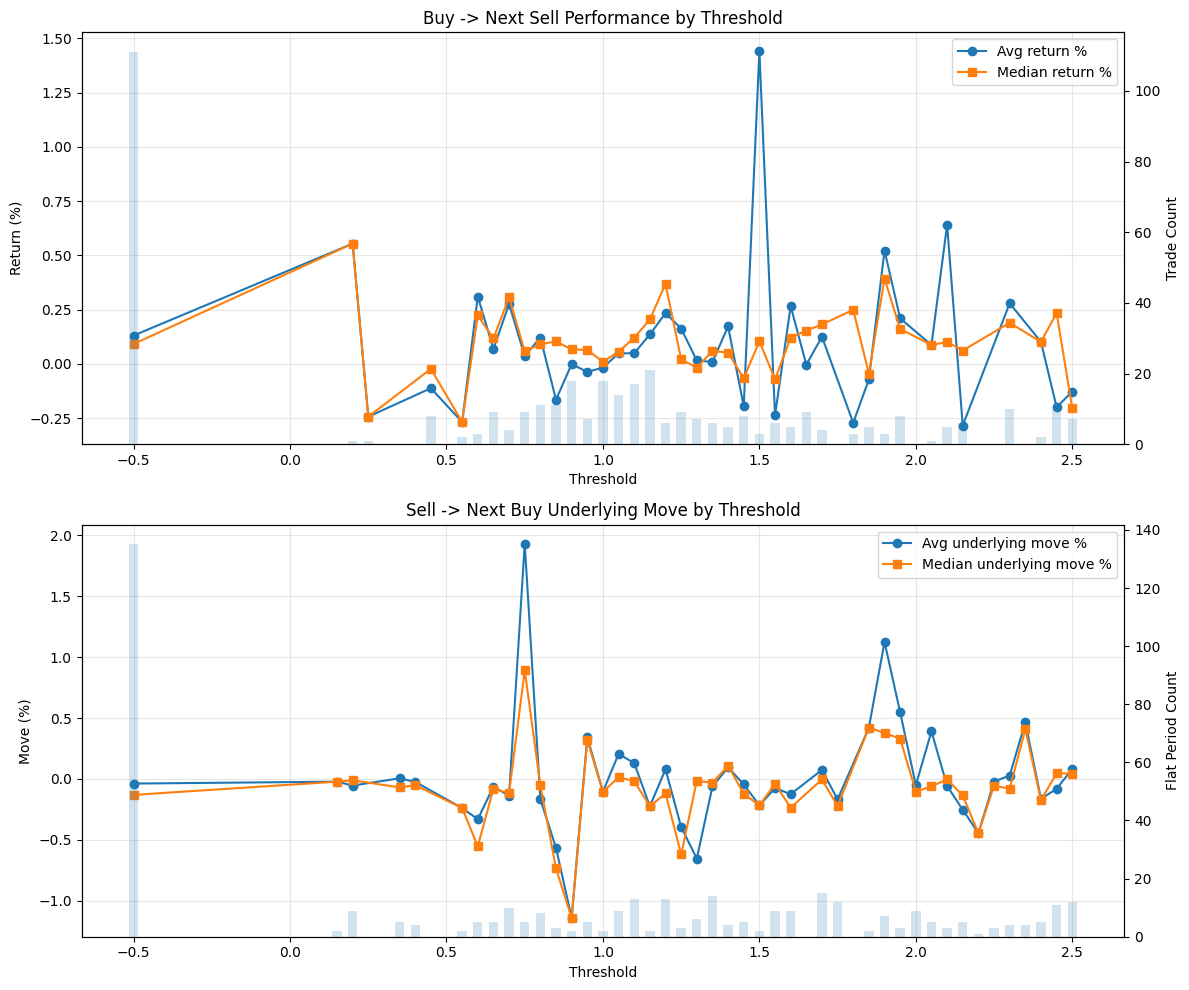

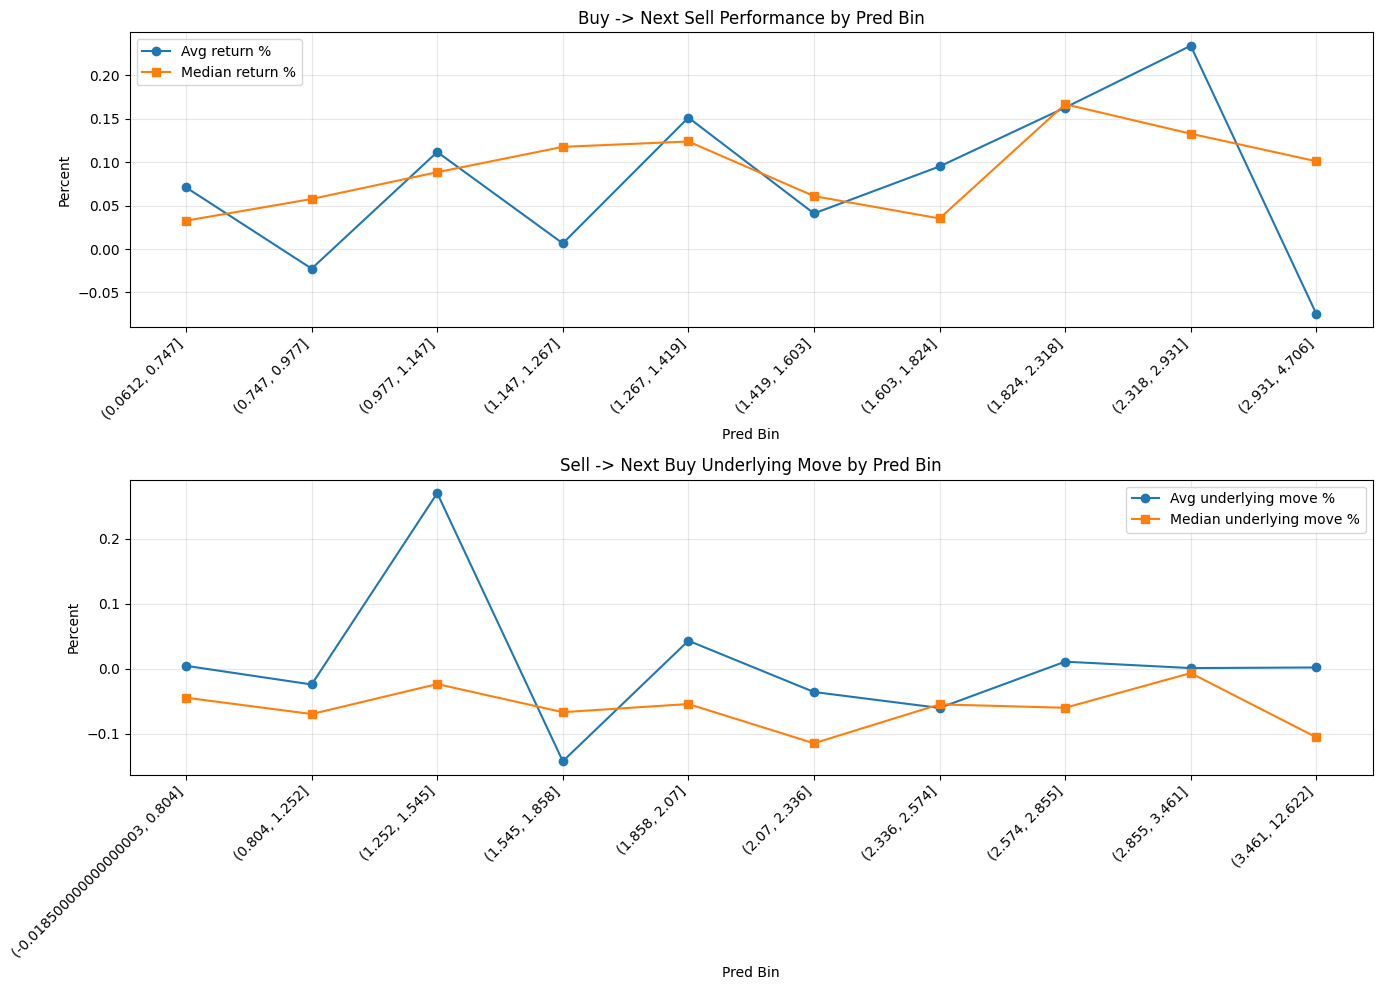

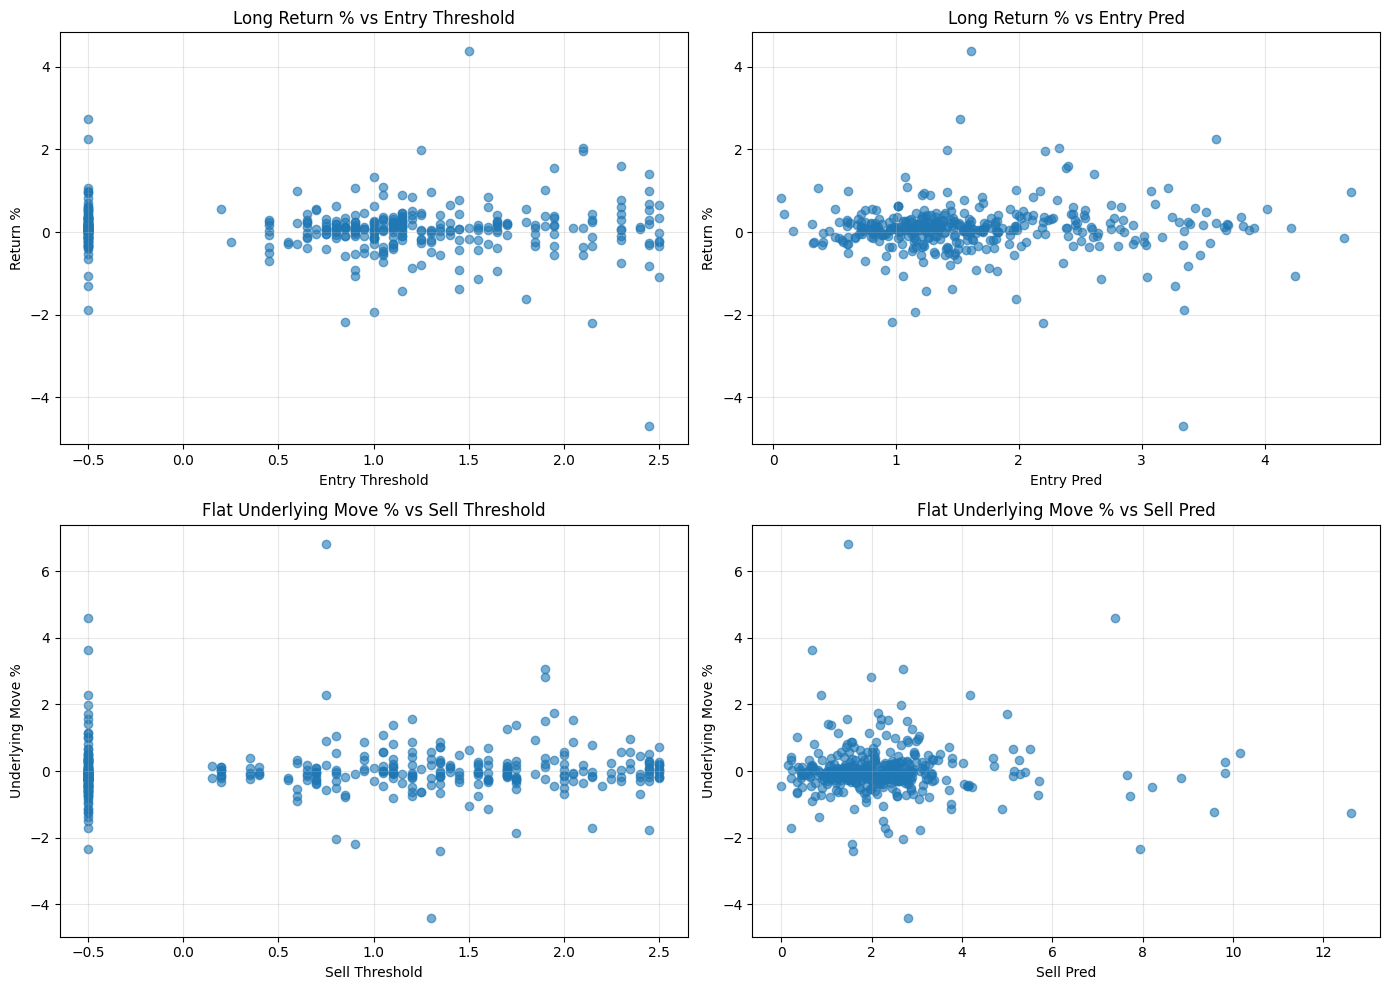

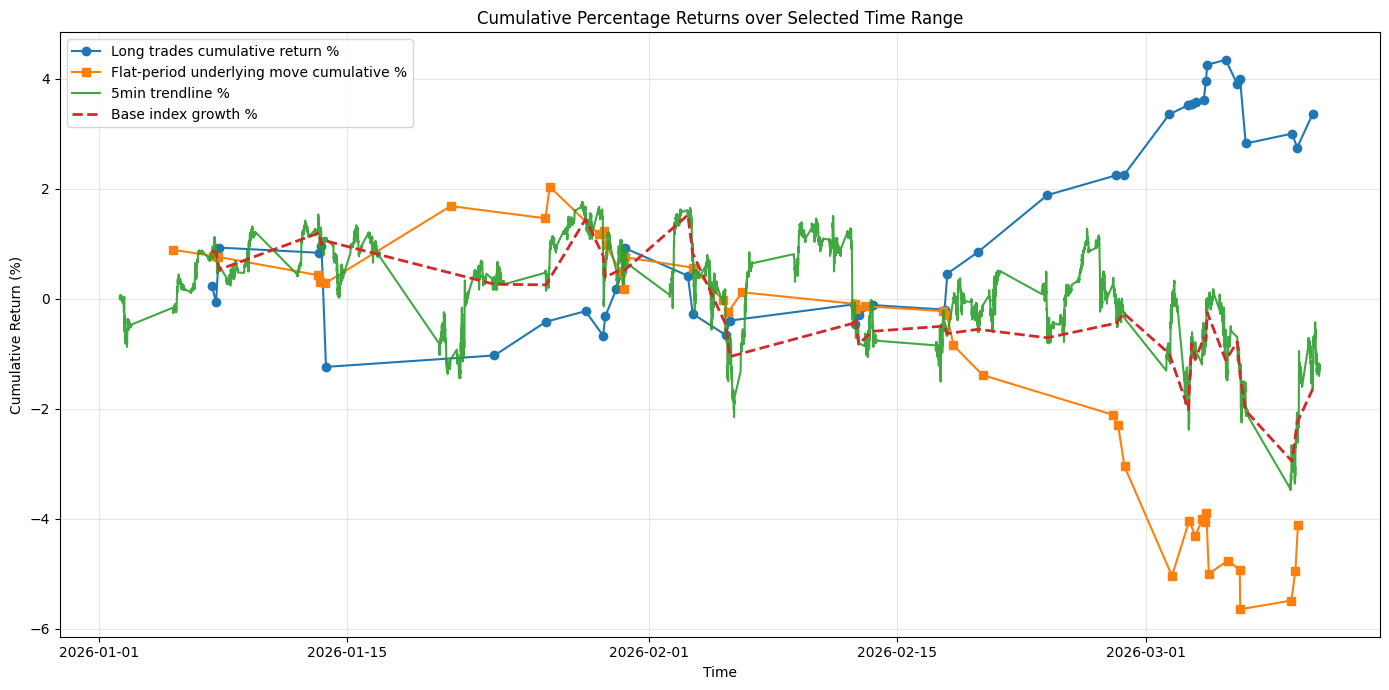

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1) LOAD + PREP
# ============================================================
def load_trades_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df = df.dropna(subset=["ts"]).sort_values("ts").reset_index(drop=True)

    # numeric cols
    num_cols = ["exec_px", "qty", "fee", "p_day", "pred", "th", "pnl", "entry_px", "entry_idx", "seen_idx"]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["side"] = df["side"].astype(str).str.lower().str.strip()
    return df


def load_price_csv(path: str) -> pd.DataFrame:
    """
    Load underlying 5m price data.
    Expected columns:
      - timestamp / datetime / date / time
      - close / Close / adj_close / Adj Close

    Returns DataFrame with:
      - timestamp
      - close
    """
    df = pd.read_csv(path)

    ts_col = None
    for c in ["timestamp", "datetime", "date", "time"]:
        if c in df.columns:
            ts_col = c
            break
    if ts_col is None:
        ts_col = df.columns[0]

    close_col = None
    for c in ["close", "Close", "adj_close", "Adj Close", "AdjClose"]:
        if c in df.columns:
            close_col = c
            break
    if close_col is None:
        raise ValueError("Could not find close column in price csv.")

    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df[close_col] = pd.to_numeric(df[close_col], errors="coerce")

    df = df.dropna(subset=[ts_col, close_col]).copy()
    df = df.sort_values(ts_col).reset_index(drop=True)

    df = df.rename(columns={ts_col: "timestamp", close_col: "close"})
    return df[["timestamp", "close"]].copy()


# ============================================================
# 2) BUILD LEGS
#    A) buy -> next sell  : in-market trade return
#    B) sell -> next buy  : out-of-market underlying move
# ============================================================
def build_trade_legs(trades: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      long_legs: buy -> next sell
      flat_legs: sell -> next buy

    long_return_pct = sell_px / buy_px - 1
    flat_underlying_move_pct = next_buy_px / sell_px - 1

    Interpretation:
      - long_return_pct > 0 means the actual long trade made money
      - flat_underlying_move_pct > 0 means price rose while you were flat
      - flat_underlying_move_pct < 0 means price fell while you were flat
    """
    trades = trades.sort_values("ts").reset_index(drop=True)

    long_rows = []
    flat_rows = []

    n = len(trades)
    for i in range(n - 1):
        a = trades.iloc[i]
        b = trades.iloc[i + 1]

        # long leg: buy -> next sell
        if a["side"] == "buy" and b["side"] == "sell":
            buy_px = float(a["exec_px"])
            sell_px = float(b["exec_px"])
            ret = (sell_px / buy_px) - 1.0 if buy_px > 0 else np.nan

            long_rows.append({
                "entry_ts": a["ts"],
                "exit_ts": b["ts"],
                "holding_minutes": (b["ts"] - a["ts"]).total_seconds() / 60.0,
                "entry_px": buy_px,
                "exit_px": sell_px,
                "return_pct": ret,
                "pnl": float(b["pnl"]) if "pnl" in b.index and pd.notna(b["pnl"]) else np.nan,
                "entry_pred": float(a["pred"]) if pd.notna(a.get("pred", np.nan)) else np.nan,
                "exit_pred": float(b["pred"]) if pd.notna(b.get("pred", np.nan)) else np.nan,
                "entry_th": float(a["th"]) if pd.notna(a.get("th", np.nan)) else np.nan,
                "exit_th": float(b["th"]) if pd.notna(b.get("th", np.nan)) else np.nan,
                "entry_p_day": float(a["p_day"]) if pd.notna(a.get("p_day", np.nan)) else np.nan,
                "exit_p_day": float(b["p_day"]) if pd.notna(a.get("p_day", np.nan)) else np.nan,
                "entry_seen_idx": float(a["seen_idx"]) if pd.notna(a.get("seen_idx", np.nan)) else np.nan,
                "exit_seen_idx": float(b["seen_idx"]) if pd.notna(b.get("seen_idx", np.nan)) else np.nan,
            })

        # flat leg: sell -> next buy
        if a["side"] == "sell" and b["side"] == "buy":
            sell_px = float(a["exec_px"])
            next_buy_px = float(b["exec_px"])
            move = (next_buy_px / sell_px) - 1.0 if sell_px > 0 else np.nan

            flat_rows.append({
                "entry_ts": a["ts"],      # when you sold / went flat
                "exit_ts": b["ts"],       # when you bought back
                "flat_minutes": (b["ts"] - a["ts"]).total_seconds() / 60.0,
                "sell_px": sell_px,
                "next_buy_px": next_buy_px,
                "underlying_move_pct": move,
                "sell_pred": float(a["pred"]) if pd.notna(a.get("pred", np.nan)) else np.nan,
                "buy_pred": float(b["pred"]) if pd.notna(b.get("pred", np.nan)) else np.nan,
                "sell_th": float(a["th"]) if pd.notna(a.get("th", np.nan)) else np.nan,
                "buy_th": float(b["th"]) if pd.notna(b.get("th", np.nan)) else np.nan,
                "sell_p_day": float(a["p_day"]) if pd.notna(a.get("p_day", np.nan)) else np.nan,
                "buy_p_day": float(b["p_day"]) if pd.notna(b.get("p_day", np.nan)) else np.nan,
                "sell_seen_idx": float(a["seen_idx"]) if pd.notna(a.get("seen_idx", np.nan)) else np.nan,
                "buy_seen_idx": float(b["seen_idx"]) if pd.notna(b.get("seen_idx", np.nan)) else np.nan,
            })

    long_legs = pd.DataFrame(long_rows)
    flat_legs = pd.DataFrame(flat_rows)
    return long_legs, flat_legs


# ============================================================
# 3) PLOT PERFORMANCE BY THRESHOLD
# ============================================================
def plot_performance_by_threshold(
    long_legs: pd.DataFrame,
    flat_legs: pd.DataFrame,
    threshold_col_long: str = "entry_th",
    threshold_col_flat: str = "sell_th",
):
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))

    # ---- long trades
    if len(long_legs) > 0 and threshold_col_long in long_legs.columns:
        g1 = (
            long_legs.dropna(subset=[threshold_col_long, "return_pct"])
            .groupby(threshold_col_long, as_index=False)
            .agg(
                avg_return_pct=("return_pct", "mean"),
                median_return_pct=("return_pct", "median"),
                n=("return_pct", "count"),
                win_rate=("return_pct", lambda x: np.mean(x > 0))
            )
            .sort_values(threshold_col_long)
        )

        axes[0].plot(g1[threshold_col_long], g1["avg_return_pct"] * 100, marker="o", label="Avg return %")
        axes[0].plot(g1[threshold_col_long], g1["median_return_pct"] * 100, marker="s", label="Median return %")
        axes[0].set_title("Buy -> Next Sell Performance by Threshold")
        axes[0].set_xlabel("Threshold")
        axes[0].set_ylabel("Return (%)")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        ax0b = axes[0].twinx()
        ax0b.bar(g1[threshold_col_long], g1["n"], alpha=0.2, width=0.03, label="Count")
        ax0b.set_ylabel("Trade Count")
    else:
        axes[0].set_title("No long legs available")

    # ---- flat periods
    if len(flat_legs) > 0 and threshold_col_flat in flat_legs.columns:
        g2 = (
            flat_legs.dropna(subset=[threshold_col_flat, "underlying_move_pct"])
            .groupby(threshold_col_flat, as_index=False)
            .agg(
                avg_move_pct=("underlying_move_pct", "mean"),
                median_move_pct=("underlying_move_pct", "median"),
                n=("underlying_move_pct", "count"),
            )
            .sort_values(threshold_col_flat)
        )

        axes[1].plot(g2[threshold_col_flat], g2["avg_move_pct"] * 100, marker="o", label="Avg underlying move %")
        axes[1].plot(g2[threshold_col_flat], g2["median_move_pct"] * 100, marker="s", label="Median underlying move %")
        axes[1].set_title("Sell -> Next Buy Underlying Move by Threshold")
        axes[1].set_xlabel("Threshold")
        axes[1].set_ylabel("Move (%)")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        ax1b = axes[1].twinx()
        ax1b.bar(g2[threshold_col_flat], g2["n"], alpha=0.2, width=0.03, label="Count")
        ax1b.set_ylabel("Flat Period Count")
    else:
        axes[1].set_title("No flat legs available")

    plt.tight_layout()
    plt.show()


# ============================================================
# 4) PLOT PERFORMANCE BY PRED
# ============================================================
def make_pred_bins(series: pd.Series, n_bins: int = 10):
    s = pd.to_numeric(series, errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)

    valid = s.dropna()
    if len(valid) < max(10, n_bins):
        return pd.Series(np.nan, index=series.index)

    try:
        return pd.qcut(s, q=n_bins, duplicates="drop")
    except Exception:
        return pd.cut(s, bins=n_bins)


def plot_performance_by_pred(
    long_legs: pd.DataFrame,
    flat_legs: pd.DataFrame,
    pred_col_long: str = "entry_pred",
    pred_col_flat: str = "sell_pred",
    n_bins: int = 10,
):
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # ---- long trades
    if len(long_legs) > 0 and pred_col_long in long_legs.columns:
        tmp = long_legs.copy()
        tmp["pred_bin"] = make_pred_bins(tmp[pred_col_long], n_bins=n_bins)

        g1 = (
            tmp.dropna(subset=["pred_bin", "return_pct"])
            .groupby("pred_bin", observed=False, as_index=False)
            .agg(
                avg_return_pct=("return_pct", "mean"),
                median_return_pct=("return_pct", "median"),
                n=("return_pct", "count"),
                win_rate=("return_pct", lambda x: np.mean(x > 0))
            )
        )

        x = np.arange(len(g1))
        labels = [str(v) for v in g1["pred_bin"]]

        axes[0].plot(x, g1["avg_return_pct"] * 100, marker="o", label="Avg return %")
        axes[0].plot(x, g1["median_return_pct"] * 100, marker="s", label="Median return %")
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(labels, rotation=45, ha="right")
        axes[0].set_title("Buy -> Next Sell Performance by Pred Bin")
        axes[0].set_xlabel("Pred Bin")
        axes[0].set_ylabel("Percent")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
    else:
        axes[0].set_title("No long legs available")

    # ---- flat periods
    if len(flat_legs) > 0 and pred_col_flat in flat_legs.columns:
        tmp = flat_legs.copy()
        tmp["pred_bin"] = make_pred_bins(tmp[pred_col_flat], n_bins=n_bins)

        g2 = (
            tmp.dropna(subset=["pred_bin", "underlying_move_pct"])
            .groupby("pred_bin", observed=False, as_index=False)
            .agg(
                avg_move_pct=("underlying_move_pct", "mean"),
                median_move_pct=("underlying_move_pct", "median"),
                n=("underlying_move_pct", "count"),
            )
        )

        x = np.arange(len(g2))
        labels = [str(v) for v in g2["pred_bin"]]

        axes[1].plot(x, g2["avg_move_pct"] * 100, marker="o", label="Avg underlying move %")
        axes[1].plot(x, g2["median_move_pct"] * 100, marker="s", label="Median underlying move %")
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(labels, rotation=45, ha="right")
        axes[1].set_title("Sell -> Next Buy Underlying Move by Pred Bin")
        axes[1].set_xlabel("Pred Bin")
        axes[1].set_ylabel("Percent")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()
    else:
        axes[1].set_title("No flat legs available")

    plt.tight_layout()
    plt.show()


# ============================================================
# 5) PLOT CUMULATIVE PERCENT RETURNS OVER A TIME RANGE
#    + BASE INDEX GROWTH
#    + 5MIN TRENDLINE
# ============================================================
def plot_cumulative_trade_returns(
    long_legs: pd.DataFrame,
    flat_legs: pd.DataFrame,
    price_df: pd.DataFrame | None = None,
    start_time: str | None = None,
    end_time: str | None = None,
    include_flat_curve: bool = True,
    include_base_index_growth: bool = True,
    include_5m_trendline: bool = True,
):
    """
    Plot cumulative returns in percentage, within [start_time, end_time].

    Lines:
      1) Long trades cumulative return %
      2) Flat-period underlying move cumulative %
      3) Base index growth cumulative % (sampled to trade timestamps)
      4) 5min trendline cumulative % (full 5m underlying close curve)

    price_df must contain:
      - timestamp
      - close
    """
    ldf = long_legs.copy()
    fdf = flat_legs.copy()
    pdf = price_df.copy() if price_df is not None else None

    if len(ldf) > 0:
        ldf["entry_ts"] = pd.to_datetime(ldf["entry_ts"])
        ldf["exit_ts"] = pd.to_datetime(ldf["exit_ts"])
    if len(fdf) > 0:
        fdf["entry_ts"] = pd.to_datetime(fdf["entry_ts"])
        fdf["exit_ts"] = pd.to_datetime(fdf["exit_ts"])
    if pdf is not None and len(pdf) > 0:
        pdf["timestamp"] = pd.to_datetime(pdf["timestamp"])
        pdf["close"] = pd.to_numeric(pdf["close"], errors="coerce")
        pdf = pdf.dropna(subset=["timestamp", "close"]).sort_values("timestamp").reset_index(drop=True)

    st = pd.to_datetime(start_time) if start_time is not None else None
    et = pd.to_datetime(end_time) if end_time is not None else None

    if st is not None:
        ldf = ldf[ldf["entry_ts"] >= st].copy()
        fdf = fdf[fdf["entry_ts"] >= st].copy()
        if pdf is not None:
            pdf = pdf[pdf["timestamp"] >= st].copy()

    if et is not None:
        ldf = ldf[ldf["entry_ts"] <= et].copy()
        fdf = fdf[fdf["entry_ts"] <= et].copy()
        if pdf is not None:
            pdf = pdf[pdf["timestamp"] <= et].copy()

    plt.figure(figsize=(14, 7))

    # ---- strategy cumulative return
    trade_time_index = None
    if len(ldf) > 0:
        ldf = ldf.sort_values("entry_ts").reset_index(drop=True)
        ldf["cum_return"] = (1.0 + ldf["return_pct"]).cumprod() - 1.0
        plt.plot(
            ldf["entry_ts"],
            ldf["cum_return"] * 100,
            marker="o",
            label="Long trades cumulative return %"
        )
        trade_time_index = pd.DatetimeIndex(ldf["entry_ts"])

    # ---- flat-period cumulative underlying move
    if include_flat_curve and len(fdf) > 0:
        fdf = fdf.sort_values("entry_ts").reset_index(drop=True)
        fdf["cum_move"] = (1.0 + fdf["underlying_move_pct"]).cumprod() - 1.0
        plt.plot(
            fdf["entry_ts"],
            fdf["cum_move"] * 100,
            marker="s",
            label="Flat-period underlying move cumulative %"
        )

    # ---- 5min trendline over the whole selected range
    if include_5m_trendline and pdf is not None and len(pdf) > 0:
        first_close = float(pdf["close"].iloc[0])
        pdf["trendline_pct"] = (pdf["close"] / first_close - 1.0) * 100.0
        plt.plot(
            pdf["timestamp"],
            pdf["trendline_pct"],
            linewidth=1.5,
            alpha=0.9,
            label="5min trendline %"
        )

    # ---- base index growth sampled to trade timestamps
    if include_base_index_growth and pdf is not None and len(pdf) > 0 and trade_time_index is not None and len(trade_time_index) > 0:
        first_close = float(pdf["close"].iloc[0])
        pdf["base_index_growth_pct"] = (pdf["close"] / first_close - 1.0) * 100.0

        base_series = pdf.set_index("timestamp")["base_index_growth_pct"].sort_index()
        base_aligned = base_series.reindex(trade_time_index, method="ffill")

        plt.plot(
            trade_time_index,
            base_aligned.values,
            linestyle="--",
            linewidth=2,
            label="Base index growth %"
        )

    plt.title("Cumulative Percentage Returns over Selected Time Range")
    plt.xlabel("Time")
    plt.ylabel("Cumulative Return (%)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 6) OPTIONAL: SCATTER PLOTS
# ============================================================
def plot_scatter_threshold_and_pred(long_legs: pd.DataFrame, flat_legs: pd.DataFrame):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    if len(long_legs) > 0:
        axes[0, 0].scatter(long_legs["entry_th"], long_legs["return_pct"] * 100, alpha=0.6)
        axes[0, 0].set_title("Long Return % vs Entry Threshold")
        axes[0, 0].set_xlabel("Entry Threshold")
        axes[0, 0].set_ylabel("Return %")
        axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].scatter(long_legs["entry_pred"], long_legs["return_pct"] * 100, alpha=0.6)
        axes[0, 1].set_title("Long Return % vs Entry Pred")
        axes[0, 1].set_xlabel("Entry Pred")
        axes[0, 1].set_ylabel("Return %")
        axes[0, 1].grid(True, alpha=0.3)

    if len(flat_legs) > 0:
        axes[1, 0].scatter(flat_legs["sell_th"], flat_legs["underlying_move_pct"] * 100, alpha=0.6)
        axes[1, 0].set_title("Flat Underlying Move % vs Sell Threshold")
        axes[1, 0].set_xlabel("Sell Threshold")
        axes[1, 0].set_ylabel("Underlying Move %")
        axes[1, 0].grid(True, alpha=0.3)

        axes[1, 1].scatter(flat_legs["sell_pred"], flat_legs["underlying_move_pct"] * 100, alpha=0.6)
        axes[1, 1].set_title("Flat Underlying Move % vs Sell Pred")
        axes[1, 1].set_xlabel("Sell Pred")
        axes[1, 1].set_ylabel("Underlying Move %")
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 7) SUMMARY TABLES
# ============================================================
def summarize_trade_performance(long_legs: pd.DataFrame, flat_legs: pd.DataFrame):
    if len(long_legs) > 0:
        print("===== LONG LEGS: BUY -> NEXT SELL =====")
        print(f"count          : {len(long_legs)}")
        print(f"avg return %   : {long_legs['return_pct'].mean() * 100:.4f}")
        print(f"median return %: {long_legs['return_pct'].median() * 100:.4f}")
        print(f"win rate %     : {(long_legs['return_pct'] > 0).mean() * 100:.2f}")
        print(f"cum return %   : {((1 + long_legs['return_pct']).prod() - 1) * 100:.4f}")
        print()

    if len(flat_legs) > 0:
        print("===== FLAT LEGS: SELL -> NEXT BUY =====")
        print(f"count                : {len(flat_legs)}")
        print(f"avg underlying move %: {flat_legs['underlying_move_pct'].mean() * 100:.4f}")
        print(f"median move %        : {flat_legs['underlying_move_pct'].median() * 100:.4f}")
        print(f"cum move %           : {((1 + flat_legs['underlying_move_pct']).prod() - 1) * 100:.4f}")
        print()


# ============================================================
# 8) EXAMPLE USAGE
# ============================================================
trades = load_trades_csv("trades.csv")
price_df = load_price_csv("SPY_5M.csv")   # <-- change this to your 5m csv path

long_legs, flat_legs = build_trade_legs(trades)

summarize_trade_performance(long_legs, flat_legs)

# 1) performance under different thresholds
plot_performance_by_threshold(long_legs, flat_legs)

# 2) performance under different pred
plot_performance_by_pred(long_legs, flat_legs, n_bins=10)

# optional scatter plots
plot_scatter_threshold_and_pred(long_legs, flat_legs)

# 3) cumulative percentage return over a chosen time range
plot_cumulative_trade_returns(
    long_legs=long_legs,
    flat_legs=flat_legs,
    price_df=price_df,
    start_time="2026-01-01",
    end_time="2026-12-31",
    include_flat_curve=True,
    include_base_index_growth=True,
    include_5m_trendline=True,
)